<h1>## we are dealing with agriculture prediction system</h1>



In [16]:
# import packages 

import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt


In [3]:
# Load the dataset
df_agri = pd.read_csv('agricluture_dataset.csv')

In [4]:
df_agri['Crop Yield (tons/ha)']

0     2.5
1     3.0
2     3.5
3     2.2
4     2.8
5     4.0
6     3.8
7     2.4
8     3.2
9     4.2
10    NaN
Name: Crop Yield (tons/ha), dtype: float64

In [5]:
df_agri['Crop Yield (tons/ha)'].values.reshape(-1, 1)

array([[2.5],
       [3. ],
       [3.5],
       [2.2],
       [2.8],
       [4. ],
       [3.8],
       [2.4],
       [3.2],
       [4.2],
       [nan]])

In [6]:


# Split data into features and target
features = df_agri[['Temperature (C)', 'Rainfall (mm)', 'Soil pH', 'Nitrogen (mg/kg)', 'Irrigation Hours', 'Fertilizer Usage (kg/ha)']].values
target = df_agri['Crop Yield (tons/ha)'].values.reshape(-1, 1)

In [7]:
features.shape , target.shape

((11, 6), (11, 1))

In [10]:
## normalize the features using Min-Max scaling
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42)

In [11]:
# Now we have data sets in numbers but we have to convert them into tensors for pytorch to work with them. So we will convert them into tensors.
# Convert data to PyTorch Tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [12]:
# Define the model using nn.Sequential
model = torch.nn.Sequential(
    torch.nn.Linear(6, 10),  # Input layer with 6 features and 10 neurons
    torch.nn.ReLU(),         # ReLU activation for the hidden layer
    torch.nn.Linear(10, 1)   # Output layer with 1 neuron
)

# Define the loss function
loss_fn = torch.nn.MSELoss()

In [23]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(6, 1)  # 6 input features → 1 output

    def forward(self, x):
        return self.linear(x)

In [25]:
# Training function for different GD methods
def train_model(optimizer, X, y, epochs=50, batch_size=None):
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        if batch_size is None:  # Batch Gradient Descent
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            epoch_loss = loss.item()
        else:
            # Mini-batch or SGD
            for i in range(0, X.size(0), batch_size):
                X_batch = X[i:i+batch_size]
                y_batch = y[i:i+batch_size]
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                epoch_loss += loss.item()
        losses.append(epoch_loss / X.size(0))
    return losses

# Train the model using Batch GD
model = NeuralNetwork()  # Reset model
optimizer_batch = torch.optim.SGD(model.parameters(), lr=0.01)
losses_batch = train_model(optimizer_batch, X_train, y_train, epochs=50)

# Train the model using Mini-Batch GD
model = NeuralNetwork()  # Reset model
optimizer_mini_batch = torch.optim.SGD(model.parameters(), lr=0.01)
losses_mini_batch = train_model(optimizer_mini_batch, X_train, y_train, epochs=50, batch_size=16)

# Train the model using Stochastic GD
model = NeuralNetwork()  # Reset model
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01)
losses_sgd = train_model(optimizer_sgd, X_train, y_train, epochs=50, batch_size=1)

In [15]:
def train_model(optimizer, X, y, epochs=50, batch_size=None):

    losses = []

    for epoch in range(epochs):

        epoch_loss = 0.0
        num_batches = 0

        if batch_size is None:
            # Batch Gradient Descent

            y_pred = model(X)
            loss = loss_fn(y_pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            epoch_loss = loss.item()
            num_batches = 1

        else:
            # Mini-Batch GD / SGD

            for i in range(0, X.size(0), batch_size):

                X_batch = X[i:i + batch_size]
                y_batch = y[i:i + batch_size]

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

                epoch_loss += loss.item()
                num_batches += 1

        losses.append(epoch_loss / num_batches)

    return losses

In [ ]:
model = NeuralNetwork()

optimizer_batch = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

losses_batch = train_model(
    optimizer_batch,
    X_train,
    y_train,
    epochs=50
)

[nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

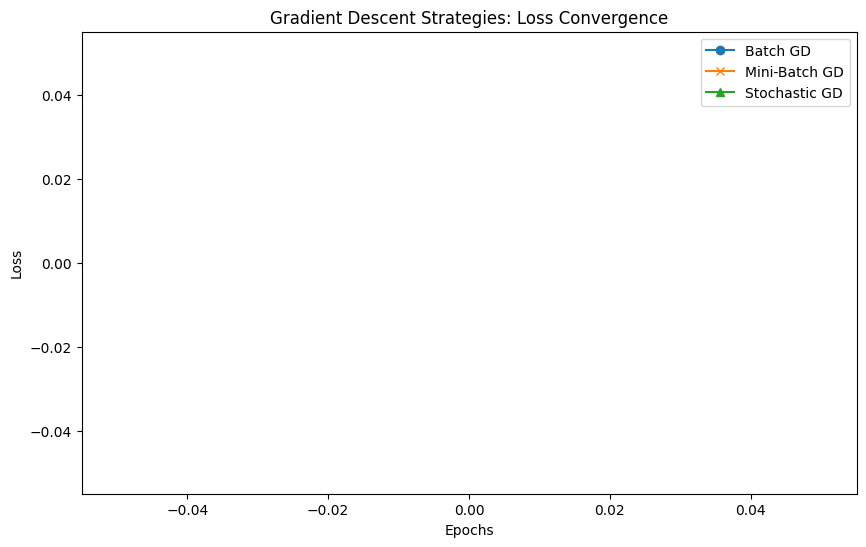

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(losses_batch, label='Batch GD', marker='o')
plt.plot(losses_mini_batch, label='Mini-Batch GD', marker='x')
plt.plot(losses_sgd, label='Stochastic GD', marker='^')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Gradient Descent Strategies: Loss Convergence')
plt.legend()
plt.show()